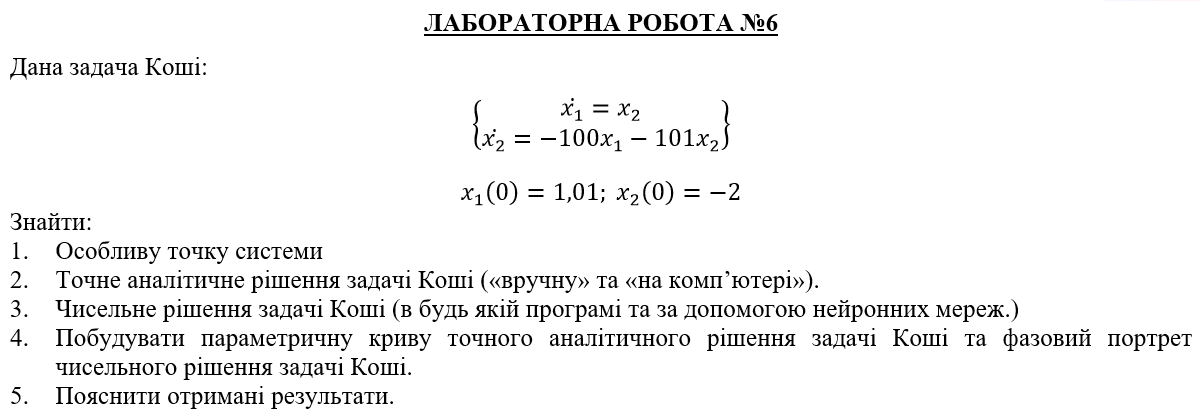

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
import sympy as sp

# Визначення власних значень
A = sp.Matrix([[0., 1.], [-100., -101.]])
eigs = A.eigenvects()
print('Власні числа матриці А:', eigs[0][0], eigs[1][0], sep = '\n')

Власні числа матриці А:
-1.00000000000000
-100.000000000000


In [2]:
# Пошук точного аналітичного рішення
t_sym = sp.symbols('t')
x1_sym = sp.Function('x1')(t_sym)
x2_sym = sp.Function('x2')(t_sym)

# Рівняння
eq1 = sp.Eq(x1_sym.diff(t_sym), x2_sym)
eq2 = sp.Eq(x2_sym.diff(t_sym), -100*x1_sym - 101*x2_sym)

# Розв'язання
sol_exact = sp.dsolve([eq1, eq2], ics={x1_sym.subs(t_sym, 0): 1.01, x2_sym.subs(t_sym, 0): -2})

# Конвертація SymPy -> NumPy
func_x1_exact = sp.lambdify(t_sym, sol_exact[0].rhs, 'numpy')
func_x2_exact = sp.lambdify(t_sym, sol_exact[1].rhs, 'numpy')

print("Точне аналітичне рішення")
print(f"x1(t) = {sol_exact[0].rhs}")
print(f"x2(t) = {sol_exact[1].rhs}")

Точне аналітичне рішення
x1(t) = 1.0*exp(-t) + 0.01*exp(-100*t)
x2(t) = -1.0*exp(-t) - 1.0*exp(-100*t)


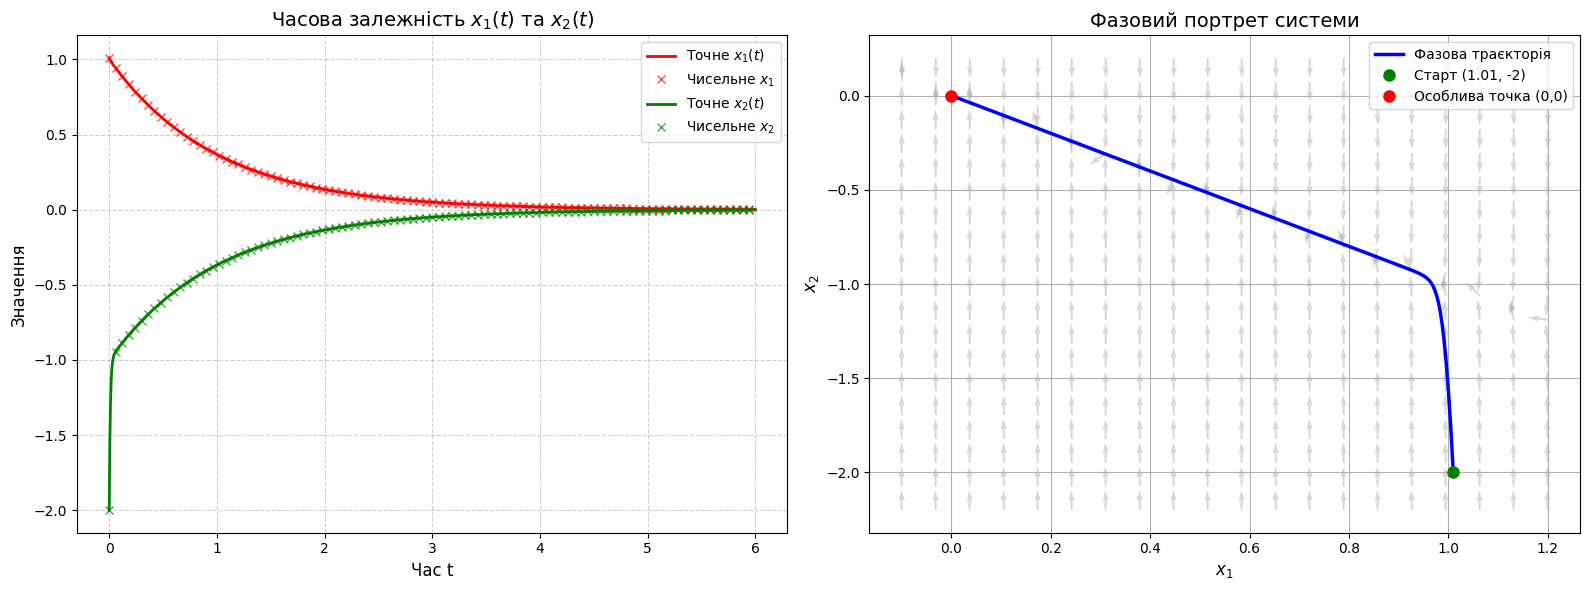

In [3]:
# Визначення системи рівнянь
def system_ode(state, t):
    x1, x2 = state
    return [x2, -100 * x1 - 101 * x2]

# Час та початкові умови
t = np.linspace(0, 6, 2000)

# Початкові умови: x1(0) = 1.01, x2(0) = -2
initial_state = [1.01, -2]

# Точні аналітичні рішення
x1_exact = func_x1_exact(t)
x2_exact = func_x2_exact(t)

# Чисельне рішення
sol_numeric = odeint(system_ode, initial_state, t)
x1_num = sol_numeric[:, 0]
x2_num = sol_numeric[:, 1]

# Побудова графіків
fig, ax = plt.subplots(1, 2, figsize=(16, 6))


#  x1
ax[0].plot(t, x1_exact, 'r-', linewidth=2, label=r'Точне $x_1(t)$')
ax[0].plot(t[::20], x1_num[::20], 'rx', label='Чисельне $x_1$', alpha=0.7)

#  x2
ax[0].plot(t, x2_exact, 'g-', linewidth=2, label=r'Точне $x_2(t)$')
ax[0].plot(t[::20], x2_num[::20], 'gx', label='Чисельне $x_2$', alpha=0.7)

ax[0].set_title("Часова залежність $x_1(t)$ та $x_2(t)$", fontsize=14)
ax[0].set_xlabel("Час t", fontsize=12)
ax[0].set_ylabel("Значення", fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend(fontsize=10)

# Фазовий портрет (x2 - x1)

# Сітка для векторного поля
X1_grid = np.linspace(-0.1, 1.2, 20)
X2_grid = np.linspace(-2.2, 0.2, 20)
X1, X2 = np.meshgrid(X1_grid, X2_grid)

# Вектори швидкості
U = X2                        # ẋ1
V = -100 * X1 - 101 * X2      # ẋ2

# Нормалізація
N = np.sqrt(U**2 + V**2)
N[N==0] = 1 # захист від ділення на 0
U, V = U/N, V/N

ax[1].quiver(X1, X2, U, V, color='gray', alpha=0.3)

# Траєкторія
ax[1].plot(x1_num, x2_num, 'b-', linewidth=2.5, label='Фазова траєкторія')
ax[1].plot(initial_state[0], initial_state[1], 'go', markersize=8, zorder=5, label='Старт (1.01, -2)')
ax[1].plot(0, 0, 'ro', markersize=8, zorder=5, label='Особлива точка (0,0)')

ax[1].set_title("Фазовий портрет системи", fontsize=14)
ax[1].set_xlabel("$x_1$", fontsize=12)
ax[1].set_ylabel("$x_2$", fontsize=12)
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

Навчання з Нормалізацією (Scaling)...
Epoch 0, Total: 100.663452, Eq1: 0.084426, Eq2: 0.177022
Epoch 1000, Total: 0.122289, Eq1: 0.005467, Eq2: 0.114848
Epoch 2000, Total: 0.029614, Eq1: 0.000178, Eq2: 0.029215
Epoch 3000, Total: 0.016685, Eq1: 0.000160, Eq2: 0.016455
Epoch 4000, Total: 0.010219, Eq1: 0.000095, Eq2: 0.010100
Epoch 5000, Total: 0.007620, Eq1: 0.000065, Eq2: 0.007539
Epoch 6000, Total: 0.005225, Eq1: 0.000060, Eq2: 0.005157
Epoch 7000, Total: 0.004053, Eq1: 0.000049, Eq2: 0.003999
Epoch 8000, Total: 0.002887, Eq1: 0.000026, Eq2: 0.002857
Epoch 9000, Total: 0.002341, Eq1: 0.000017, Eq2: 0.002321


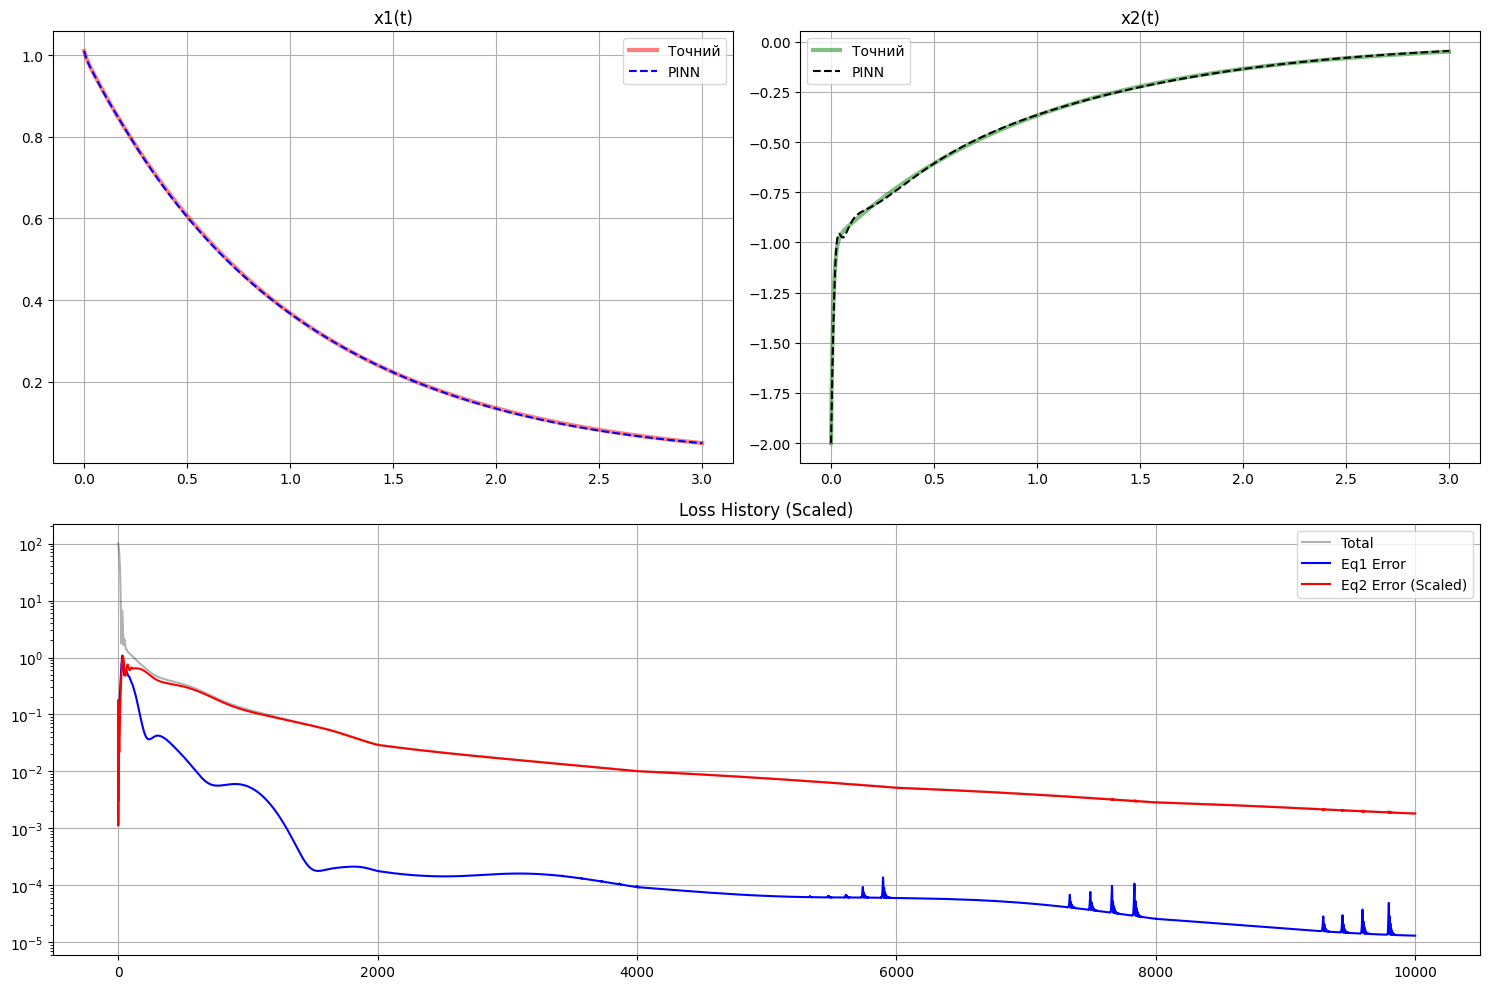

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# Побудова нейромережі
class SystemPINN(nn.Module):
    def __init__(self):
        super(SystemPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2)
        )
        self.init_weights()

    def init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

def get_derivatives(model, t):
    t.requires_grad = True
    outputs = model(t)
    x1, x2 = outputs[:, 0:1], outputs[:, 1:2]

    dx1 = torch.autograd.grad(x1, t, torch.ones_like(x1), create_graph=True)[0]
    dx2 = torch.autograd.grad(x2, t, torch.ones_like(x2), create_graph=True)[0]
    return x1, x2, dx1, dx2

#  Налаштування
torch.manual_seed(42)
np.random.seed(42)

model = SystemPINN()


t_train = torch.cat([
    torch.linspace(0, 0.2, 300),
    torch.linspace(0.2, 1.0, 200),
    torch.linspace(1.0, 3.0, 100)
]).view(-1, 1)


optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

history_total = []
history_eq1 = []
history_eq2 = []

print("Навчання з Нормалізацією (Scaling)...")

epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()

    x1, x2, dx1, dx2 = get_derivatives(model, t_train)

    #  МАСШТАБУВАННЯ

    # Рівняння 1: x1' - x2 = 0 маленькі значення, лишаємо як є
    res1 = dx1 - x2
    loss_eq1 = torch.mean(res1**2)

    # Рівняння 2: x2' + 100x1 + 101x2 = 0
    # Значення величезні (~100). Ділимо на 100
    res2 = (dx2 + 100*x1 + 101*x2) / 100.0
    loss_eq2 = torch.mean(res2**2)

    # Physics Loss
    loss_ode = loss_eq1 + loss_eq2

    # Boundary Loss (Soft constraints)
    t0 = torch.tensor([[0.0]], requires_grad=True)
    x1_0, x2_0, _, _ = get_derivatives(model, t0)

    loss_ic = (x1_0 - 1.01)**2 + (x2_0 - (-2))**2

    # Total Loss
    loss = loss_ode + 20.0 * loss_ic

    loss.backward()
    optimizer.step()
    scheduler.step()

    history_total.append(loss.item())
    history_eq1.append(loss_eq1.item())
    history_eq2.append(loss_eq2.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Total: {loss.item():.6f}, Eq1: {loss_eq1.item():.6f}, Eq2: {loss_eq2.item():.6f}")

# Візуалізація
t_test = torch.linspace(0, 3, 1000).view(-1, 1)
with torch.no_grad():
    outputs = model(t_test).numpy()
    x1_nn, x2_nn = outputs[:, 0], outputs[:, 1]

t_val = t_test.numpy().flatten()
x1_exact = np.exp(-t_val) + 0.01 * np.exp(-100 * t_val)
x2_exact = -np.exp(-t_val) - np.exp(-100 * t_val)

plt.figure(figsize=(15, 10))

# Графік x1
plt.subplot(2, 2, 1)
plt.plot(t_val, x1_exact, 'r-', lw=3, alpha=0.5, label='Точний')
plt.plot(t_val, x1_nn, 'b--', label='PINN')
plt.title('x1(t)')
plt.legend(); plt.grid(True)

# Графік x2
plt.subplot(2, 2, 2)
plt.plot(t_val, x2_exact, 'g-', lw=3, alpha=0.5, label='Точний')
plt.plot(t_val, x2_nn, 'k--', label='PINN')
plt.title('x2(t)')
plt.legend(); plt.grid(True)

# Графік помилок
plt.subplot(2, 1, 2)
plt.plot(history_total, 'k-', alpha=0.3, label='Total')
plt.plot(history_eq1, 'b-', label='Eq1 Error')
plt.plot(history_eq2, 'r-', label='Eq2 Error (Scaled)')
plt.yscale('log')
plt.title('Loss History (Scaled)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()
